# 03 — Phase 2 Envelope Forecasting

Fine-tune the forecast head on frozen encoder; evaluate coverage on the test split.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for _ in range(3):
    if (PROJECT_ROOT / "src_regi").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    raise RuntimeError("Open notebook under Advanced Machine Learning Project")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src_regi.train_phase2 import main

In [2]:
main(str(PROJECT_ROOT / "config_regi.json"), epochs=10)

Epoch 1/10 | train=0.2065 | val=0.4852


Epoch 2/10 | train=0.1648 | val=0.4845


Epoch 3/10 | train=0.1597 | val=0.5251


Epoch 4/10 | train=0.1583 | val=0.5812


Epoch 5/10 | train=0.1561 | val=0.5435


Epoch 6/10 | train=0.1544 | val=0.5357


Epoch 7/10 | train=0.1544 | val=0.6157


Epoch 8/10 | train=0.1526 | val=0.5142


Epoch 9/10 | train=0.1524 | val=0.5958


Epoch 10/10 | train=0.1518 | val=0.6061
Early stopping at epoch 10
Test metrics: {'loss': 0.7365610003471375, 'mae_max': 1.2280596719738663, 'mae_min': 3.678683358004808, 'coverage': 0.0, 'mean_pred_range': 2.516736923827483, 'mean_true_range': 0.06611323779654088}
Phase 2 complete. Checkpoint: /home/efiareg/OneDrive/advanced_ml/AdvancedML_drive/Advanced Machine Learning Project/artifacts_regi/phase2_head.pt


In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from src_regi.config import artifacts_dir, load_config
from src_regi.data import prepare_data
from src_regi.datasets import build_dataloaders
from src_regi.evaluate import evaluate_predictions, predict_envelopes
from src_regi.forecast_head import ForecastHead
from src_regi.train_phase2 import build_encoder_from_checkpoint
from src_regi.utils import get_device, load_checkpoint

cfg = load_config(PROJECT_ROOT / "config_regi.json")
device = get_device()
art = artifacts_dir(cfg)
ckpt1 = load_checkpoint(art / "phase1_best.pt", map_location=device)
ckpt2 = load_checkpoint(art / "phase2_head.pt", map_location=device)
prepared = prepare_data(cfg)
seq_len = cfg["data"]["sequence_length"]
num_features = len(prepared.feature_columns)

encoder = build_encoder_from_checkpoint(cfg, ckpt1, num_features, seq_len, device)
head = ForecastHead(d_latent=cfg["model"]["d_latent"]).to(device)
head.load_state_dict(ckpt2["forecast_head"])

loader = build_dataloaders(prepared, seq_len, 64, phase="phase2")["test"]
pred_max, pred_min, true_max, true_min = predict_envelopes(
    encoder, head, loader, device,
    envelope_mean=ckpt1.get("envelope_mean"),
    envelope_scale=ckpt1.get("envelope_scale"),
)
metrics = evaluate_predictions(pred_max, pred_min, true_max, true_min, loss_type=cfg["training"]["loss"])
print(metrics)

{'loss': 0.631970226764679, 'mae_max': 1.004667812413754, 'mae_min': 3.5973946625700006, 'coverage': 0.0, 'mean_pred_range': 2.6588400879527874, 'mean_true_range': 0.06611323779654088}


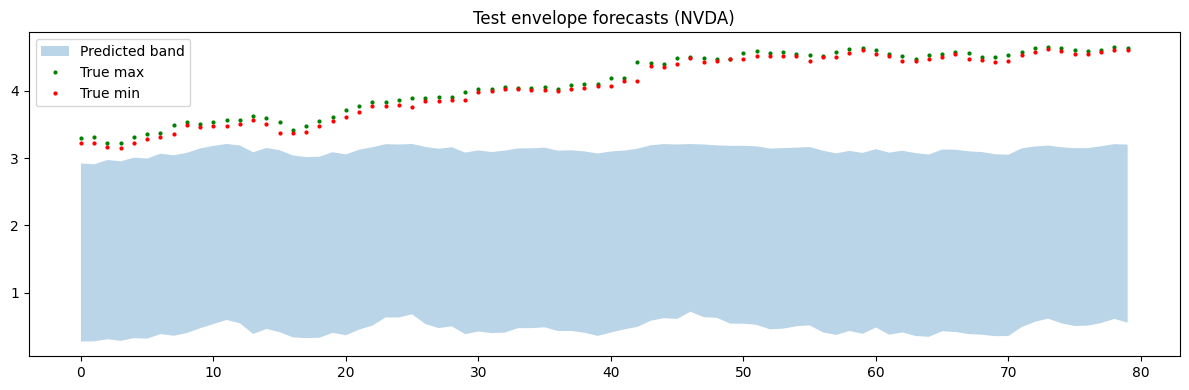

In [4]:
n_show = 80
idx = np.linspace(0, len(pred_max) - 1, n_show, dtype=int)
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(range(n_show), pred_min[idx], pred_max[idx], alpha=0.3, label="Predicted band")
ax.plot(range(n_show), true_max[idx], "g.", label="True max", markersize=4)
ax.plot(range(n_show), true_min[idx], "r.", label="True min", markersize=4)
ax.set_title(f"Test envelope forecasts ({cfg['data']['target_ticker']})")
ax.legend()
plt.tight_layout()
plt.show()